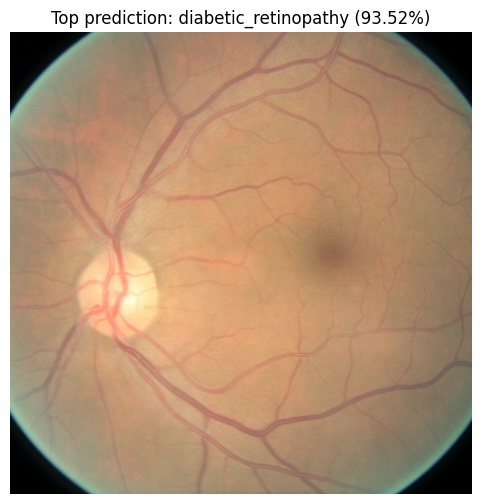

Top-k predictions:
 1. diabetic_retinopathy       93.52%
 2. cataract                    2.72%
 3. glaucoma                    1.93%


In [10]:
# Inference snippet for Jupyter notebook
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
import io

# --- Config ---
MODEL_SAVE_PATH = "best_multiclass_eye_disease_resnet152_model.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TOP_K = 3   # how many top predictions to show

# --- Preprocessing (must match your val/test transforms) ---
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Helper: load checkpoint and build model ---
def load_model_from_checkpoint(checkpoint_path, device=DEVICE):
    # Load checkpoint dict (works for checkpoint saved by your training script)
    import torch

    checkpoint = torch.load("best_multiclass_eye_disease_resnet152_model.pth",map_location=torch.device("cpu"), weights_only=False)   # allow full unpickling

    # Get num_classes (fallback to inferring from class_names or explicit key)
    num_classes = checkpoint.get('num_classes', None)
    class_names = checkpoint.get('class_names', None)
    if num_classes is None and class_names is not None:
        num_classes = len(class_names)
    if num_classes is None:
        raise RuntimeError("Could not determine num_classes from checkpoint. "
                           "Make sure 'num_classes' or 'class_names' is saved in the checkpoint.")
    # Instantiate model architecture and replace fc
    model = models.resnet152(weights=None)   # weights=None to avoid downloading
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    # Load state dict (expect 'model_state_dict' in your saved checkpoint)
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    # If class_names not saved, create numeric labels
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]
    return model, class_names

# --- Helper: predict on a PIL image ---
def predict_pil_image(pil_img, model, class_names, preprocess, device=DEVICE, top_k=TOP_K):
    # Preprocess
    x = preprocess(pil_img).unsqueeze(0).to(device)  # shape [1, C, H, W]
    with torch.no_grad():
        logits = model(x)                 # raw logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    # top-k
    topk_idx = np.argsort(probs)[::-1][:top_k]
    topk = [(class_names[i], float(probs[i])) for i in topk_idx]
    return topk, probs

# --- Upload image (Jupyter) ---
# If you're in a notebook, you can use file upload widget, or simply open a local path:
# Example (local file):
img_path = "119_right.jpeg"   # replace with your image path or uploaded file
pil_img = Image.open(img_path).convert("RGB")

# --- Load model and run prediction ---
model, class_names = load_model_from_checkpoint(MODEL_SAVE_PATH, device=DEVICE)
topk, probs = predict_pil_image(pil_img, model, class_names, preprocess, device=DEVICE, top_k=TOP_K)

# --- Display results ---
plt.figure(figsize=(6,6))
plt.imshow(pil_img)
plt.axis('off')
plt.title(f"Top prediction: {topk[0][0]} ({topk[0][1]*100:.2f}%)")
plt.show()

print("Top-k predictions:")
for i,(label, p) in enumerate(topk, 1):
    print(f" {i}. {label:25s} {p*100:6.2f}%")
